In [1]:
import requests
import pandas as pd
import numpy as np
import importlib
import matplotlib.pyplot as plt
import py_files.dk_emp_tax as dk_emp_tax
import py_files.fig_setup as fs
importlib.reload(fs)     
fs.set_aej()

from io import StringIO
from dataclasses import dataclass
from py_files.capinc import CapIncModel

# `Interest rate` data fetch

Possible source for addition: https://www.oecd.org/en/data/datasets/corporate-income-tax-rates-database.html
- Corporate income tax (CIT) - statutory and targeted small business rates
- 2000: 32% and 2025: 22%

https://data-explorer.oecd.org/vis?fs[0]=Topic%2C1%7CTaxation%23TAX%23%7CCorporate%20tax%23TAX_CPT%23&pg=0&fc=Topic&bp=true&snb=19&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_TAX_CIT%40DF_CIT&df[ag]=OECD.CTP.TPS&df[vs]=2.0&dq=DNK.A.CIT.ST..S13%2BS1311%2BS13M...&pd=2000%2C2025&to[TIME_PERIOD]=false&vw=tl

Using API, I get CIT data for DK from 2020-2025:

In [2]:
url = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.CTP.TPS,DSD_TAX_CIT@DF_CIT,1.0/"
    "DNK.A..ST..S13+S1311+S13M.."
    "?startPeriod=2000&endPeriod=2025"
    "&dimensionAtObservation=AllDimensions"
    "&format=csvfilewithlabels"
)

r = requests.get(url)

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))

# keep only the statutory CIT rate
df_cit = (df.loc[df["MEASURE"] == "CIT", ["TIME_PERIOD", "OBS_VALUE"]]
            .rename(columns={"TIME_PERIOD": "year", "OBS_VALUE": "cit_rate"})
            .assign(year=lambda x: x["year"].astype(int))
            .sort_values("year")
            .reset_index(drop=True))

*compare with alternative path $\{\tau\}_t^T$*

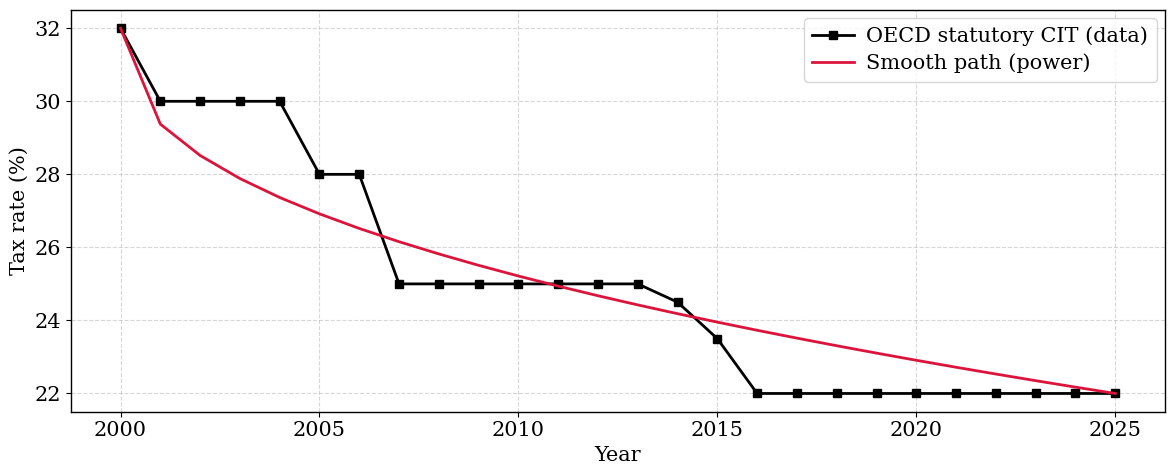

In [3]:
y0 = int(df_cit["year"].min())
yT = int(df_cit["year"].max())
T  = yT - y0

tau0 = df_cit.loc[df_cit["year"] == y0, "cit_rate"].iloc[0] / 100
tauT = df_cit.loc[df_cit["year"] == yT, "cit_rate"].iloc[0] / 100

_, tau_t, _ = dk_emp_tax.net_tax_path_power(T=T, tau0=tau0, tauT=tauT, kappa=0.4)
years_model = np.arange(y0, yT + 1)

# --- plot ---
plt.figure(figsize=(12, 5))
plt.plot(df_cit["year"], df_cit["cit_rate"], linewidth=2, marker="s", label="OECD statutory CIT (data)", color='k')
plt.plot(years_model, 100 * tau_t, linewidth=2, label=r"Smooth path (power)", color='crimson')
plt.xlabel("Year")
plt.ylabel("Tax rate (%)")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

*make alternative simulation, using empirical path*